# Langage des signes

=== Résumé des datasets ===
Learning dataset : 250 exemples
Répartition learning : {0: 50, 1: 50, 2: 50, 3: 50, 4: 50}
Validation dataset : 50 exemples
Répartition validation : {0: 10, 1: 10, 2: 10, 3: 10, 4: 10}


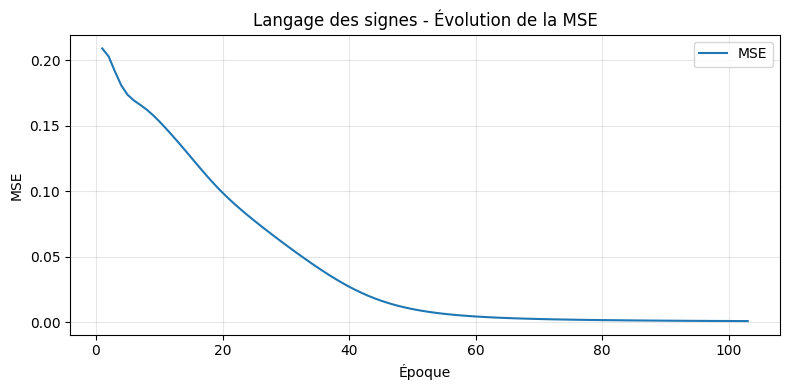

Accuracy sur le learning dataset   = 1.0000
Accuracy sur le validation dataset = 1.0000


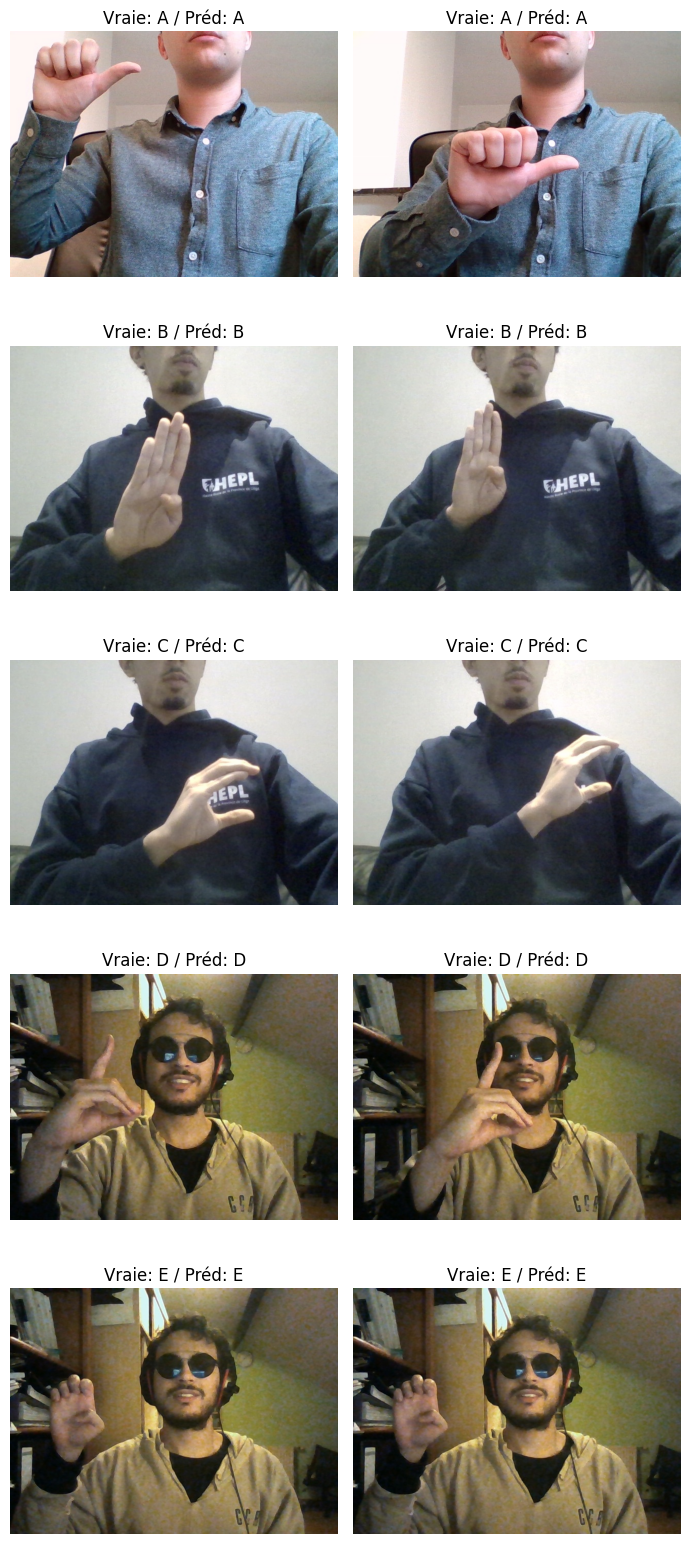

In [1]:
from neural_network import NeuralNetwork, Layer, TrainingType, ActivationFunction, MetricType
from neural_network.utils import (load_csv_dataset, split_dataset_by_class_with_indices, print_dataset_summary, plot_metric, multiclass_accuracy, load_numbered_image_paths, plot_sign_language_predictions_balanced)

x_signs, y_signs = load_csv_dataset(
    "data/LangageDesSignes/data_formatted.csv",
    target_columns=5,
    has_header=False
)

x_train_signs, y_train_signs, train_indices, x_val_signs, y_val_signs, val_indices = split_dataset_by_class_with_indices(
    x_signs,
    y_signs,
    train_per_class=50,
    validation_per_class=10
)

print_dataset_summary(x_train_signs, y_train_signs, x_val_signs, y_val_signs)


signs_model = NeuralNetwork()
signs_model.add_layer(Layer(n_inputs=len(x_train_signs[0]), n_neurons=15, activation=ActivationFunction.SIGMOID))
signs_model.add_layer(Layer(n_inputs=15, n_neurons=5, activation=ActivationFunction.SIGMOID))

history_signs = signs_model.train(
    x_train=x_train_signs,
    y_train=y_train_signs,
    epochs=10000,
    learning_rate=0.1,
    strategy=TrainingType.STOCHASTIC,
    verbose=False,
    metrics=(MetricType.MSE,),
    update_on_error_only=False,
    mse_threshold=0.001,
    classification_threshold=0.5
)

plot_metric(history_signs, MetricType.MSE, "Langage des signes - Évolution de la MSE")


train_acc_signs = multiclass_accuracy(signs_model, x_train_signs, y_train_signs)
val_acc_signs = multiclass_accuracy(signs_model, x_val_signs, y_val_signs)

print(f"Accuracy sur le learning dataset   = {train_acc_signs:.4f}")
print(f"Accuracy sur le validation dataset = {val_acc_signs:.4f}")


image_paths = load_numbered_image_paths("data/LangageDesSignes/Pictures")
val_image_paths = [image_paths[i] for i in val_indices]

plot_sign_language_predictions_balanced(
    signs_model,
    x_val_signs,
    y_val_signs,
    val_image_paths,
    class_names=["A", "B", "C", "D", "E"],
    samples_per_class=2
)